# Adding Momentum to an existing portfolio

This notebook measures what a **Momentum** sleeve does to a book you already
run: how correlated the two are, and how the blend's risk and return compare
before and after. Portfolios are the published **Top-40, unlevered (1x)**
returns.

**Prerequisites: none** -- runs on the shared public demo key (preview data);
set `APERIODIC_API_KEY` for full data.

Licence: MIT

In [1]:
# Install the notebook's full dependency closure first, so it is self-contained
# when run standalone (e.g. Google Colab). This must precede the collapsed
# helper cell below, whose imports (matplotlib / numpy / pandas / dotenv) would
# otherwise fail on a fresh environment. `pip install -r requirements.txt` (see
# the README) already covers this if you cloned the repo.
import sys

!{sys.executable} -m pip install -q aperiodic-factors python-dotenv matplotlib numpy pandas

In [2]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
# --- Utility functions (inlined so this notebook is self-contained). ---
# This cell is collapsed by default when the notebook is rendered; expand it to
# see the helpers below.
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# The factors API serves preview data against a shared public demo key, so the
# notebook runs out-of-the-box with no signup. Export APERIODIC_API_KEY (or set
# it in a .env file) to query with your own key for full access.
DEMO_API_KEY = "DEMO-KEY"


def get_api_key() -> str:
    try:
        load_dotenv()
    except Exception:  # noqa: BLE001
        warnings.warn("Could not load .env")  # noqa: B028
    return os.environ.get("APERIODIC_API_KEY") or DEMO_API_KEY


def perf_stats(returns: pd.Series) -> dict:
    # Headline stats for a daily return series: CAGR, annualized volatility,
    # Sharpe (sqrt(365) for daily crypto) and max drawdown.
    returns = pd.to_numeric(returns, errors="coerce").dropna()
    if returns.empty or returns.std() == 0:
        nan = float("nan")
        return {"CAGR": nan, "Vol": nan, "Sharpe": nan, "Max drawdown": nan}
    curve = (1 + returns).cumprod()
    years = len(returns) / 365
    cagr = curve.iloc[-1] ** (1 / years) - 1 if years > 0 else float("nan")
    vol = returns.std() * np.sqrt(365)
    sharpe = returns.mean() / returns.std() * np.sqrt(365)
    max_drawdown = (curve / curve.cummax() - 1).min()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "Max drawdown": max_drawdown}


def plot_cumulative_and_drawdown(series_by_label: dict) -> None:
    # Two stacked panels: cumulative growth of 1 unit, and drawdown from peak.
    fig, (ax_cum, ax_dd) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )
    for label, series in series_by_label.items():
        curve = (1 + pd.to_numeric(series, errors="coerce").dropna()).cumprod()
        ax_cum.plot(curve.index, curve.values, label=label)
        ax_dd.plot(curve.index, (curve / curve.cummax() - 1).values, label=label)
    ax_cum.set_title("Cumulative growth of 1 unit")
    ax_cum.set_ylabel("Growth")
    ax_cum.legend()
    ax_dd.set_title("Drawdown")
    ax_dd.set_ylabel("Drawdown")
    ax_dd.axhline(0, color="black", linewidth=0.8)
    fig.tight_layout()
    plt.show()

### Parameters

- **APERIODIC_API_KEY** -- optional. Falls back to a Google Colab secret, then
  a local `.env` / environment variable, then the shared public **demo key**
  (preview data), so the notebook runs as-is.
- **FACTOR_PORTFOLIOS** -- the published portfolio slug(s) that make up the
  sleeve: one for a single factor, the constituents for a composite.
- **EXISTING_PORTFOLIO_RETURNS_CSV** -- path or URL to your own daily
  `date,return` CSV. `None` blends against a synthetic demo book instead.
- **ALLOCATION** -- the fraction of the book reallocated into the sleeve.
- **START_DATE** -- earliest date to include.

In [3]:
# Resolve the API key with the same ladder as the multi-factor notebook: a Google
# Colab secret, then a local .env / environment variable, then the shared public
# demo key (preview data) so the notebook runs with no signup.
try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    try:
        APERIODIC_API_KEY = userdata.get("APERIODIC_API_KEY") or DEMO_API_KEY
    except Exception:  # noqa: BLE001 -- secret not set / access denied
        APERIODIC_API_KEY = DEMO_API_KEY
else:
    APERIODIC_API_KEY = get_api_key()

import aperiodic_factors as aperiodic
from aperiodic_factors import get_portfolio_returns

# Published portfolio slug(s) whose returns make up the factor sleeve. A single
# factor has one slug; a composite lists its constituents, ensembled below.
FACTOR_PORTFOLIOS = ['momentum.40']
FACTOR_LABEL = "Momentum"
# Your own daily return series (a `date,return` CSV). None -> synthetic demo book.
EXISTING_PORTFOLIO_RETURNS_CSV = None
# Fraction of the book reallocated into the factor sleeve.
ALLOCATION = 0.20
# Ignore history before this date.
START_DATE = "2021-01-01"

print("**Parameters:**")
print(f"FACTOR_PORTFOLIOS: {FACTOR_PORTFOLIOS}")
print(f"FACTOR_LABEL: {FACTOR_LABEL}")
print(f"EXISTING_PORTFOLIO_RETURNS_CSV: {EXISTING_PORTFOLIO_RETURNS_CSV}")
print(f"ALLOCATION: {ALLOCATION}")
print(f"START_DATE: {START_DATE}")

**Parameters:**
FACTOR_PORTFOLIOS: ['momentum.40']
FACTOR_LABEL: Momentum
EXISTING_PORTFOLIO_RETURNS_CSV: None
ALLOCATION: 0.2
START_DATE: 2021-01-01


### Your existing portfolio

Supply your own daily return series via `EXISTING_PORTFOLIO_RETURNS_CSV` (a
`date,return` CSV). Left as `None`, we fall back to a demo book: 60/40
BTC-ETH, bought and held, rebalanced daily.

In [4]:
if EXISTING_PORTFOLIO_RETURNS_CSV:
    existing = pd.read_csv(
        EXISTING_PORTFOLIO_RETURNS_CSV, index_col=0, parse_dates=True
    ).squeeze("columns")
    existing = pd.to_numeric(existing, errors="coerce").dropna()
    existing.name = "Existing book"
else:
    # No book supplied -> synthesize a 60/40 BTC-ETH book, rebalanced daily,
    # from published close prices. A pandas Series of weights aligns by ticker
    # label, so the column order the API returns does not matter.
    DEMO_WEIGHTS = pd.Series({"BTC": 0.6, "ETH": 0.4})
    prices = aperiodic.get_prices(
        tickers=list(DEMO_WEIGHTS.index),
        api_key=APERIODIC_API_KEY,
        start_date=START_DATE,
    )
    asset_returns = (
        prices.reindex(columns=DEMO_WEIGHTS.index)
        .apply(pd.to_numeric, errors="coerce")
        .pct_change()
    )
    # min_count so a day missing a ticker (or the first, price-less day) stays
    # NaN and is dropped, rather than silently collapsing to a reweighted book.
    existing = (
        (asset_returns * DEMO_WEIGHTS)
        .sum(axis=1, min_count=len(DEMO_WEIGHTS))
        .dropna()
    )
    existing.name = "Existing book (demo 60/40 BTC-ETH)"

existing = existing[existing.index >= pd.Timestamp(START_DATE)]
print(
    f"Existing book: {len(existing)} daily returns "
    f"({existing.index.min().date()} to {existing.index.max().date()})"
)

Existing book: 1992 daily returns (2021-01-02 to 2026-06-16)


### The factor sleeve

The sleeve is the published, unlevered (1x) daily returns of the **Momentum** top-40 portfolio.

In [5]:
# Fetch each constituent portfolio's published returns and equal-weight them.
# For a single factor FACTOR_PORTFOLIOS holds one slug, so this reduces to that
# factor's own returns.
parts = {
    pid: pd.to_numeric(
        get_portfolio_returns(id=pid, api_key=APERIODIC_API_KEY), errors="coerce"
    )
    for pid in FACTOR_PORTFOLIOS
}
# dropna() before the mean so the sleeve only spans dates where *every*
# constituent has published returns; otherwise a partial row would silently
# become an equal-weight average of fewer factors than advertised.
sleeve = pd.DataFrame(parts).dropna().mean(axis=1)
sleeve.name = FACTOR_LABEL

# Inner-join the sleeve to the book on their shared trading days, then clip to
# START_DATE so every comparison below spans the same window.
aligned = pd.concat({"existing": existing, "sleeve": sleeve}, axis=1).dropna()
aligned = aligned[aligned.index >= pd.Timestamp(START_DATE)]
existing_aligned = aligned["existing"]
sleeve_aligned = aligned["sleeve"]
print(
    f"Aligned sample: {len(aligned)} shared trading days "
    f"({aligned.index.min().date()} to {aligned.index.max().date()})"
)

Aligned sample: 1992 shared trading days (2021-01-02 to 2026-06-16)


### How the sleeve relates to your book

The full-sample correlation and its 90-day rolling version. A low or negative
correlation means the sleeve carries a return stream your book does not
already own.

Full-sample correlation (Momentum sleeve vs your book): 0.071


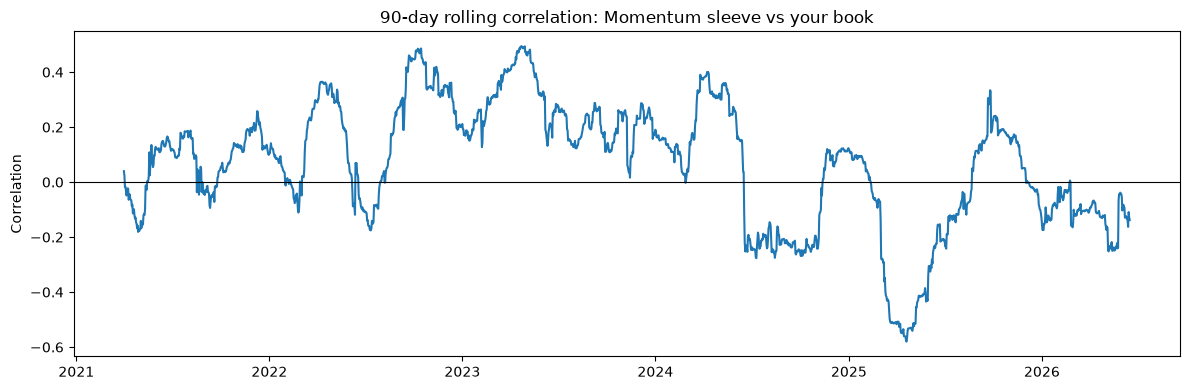

In [6]:
correlation = existing_aligned.corr(sleeve_aligned)
print(
    f"Full-sample correlation ({FACTOR_LABEL} sleeve vs your book): {correlation:.3f}"
)

rolling_correlation = existing_aligned.rolling(90).corr(sleeve_aligned)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_correlation.index, rolling_correlation.values)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"90-day rolling correlation: {FACTOR_LABEL} sleeve vs your book")
ax.set_ylabel("Correlation")
fig.tight_layout()
plt.show()

### Before and after the blend

Reallocating `ALLOCATION` of the book into the sleeve, then comparing the
blended series against the original on CAGR, volatility, Sharpe and max
drawdown.

                  CAGR    Vol  Sharpe  Max drawdown
Existing book   0.1951 0.6271  0.5988       -0.7626
Momentum sleeve 0.1992 0.3476  0.7005       -0.3664
Blended (20%)   0.2435 0.5113  0.6827       -0.6833


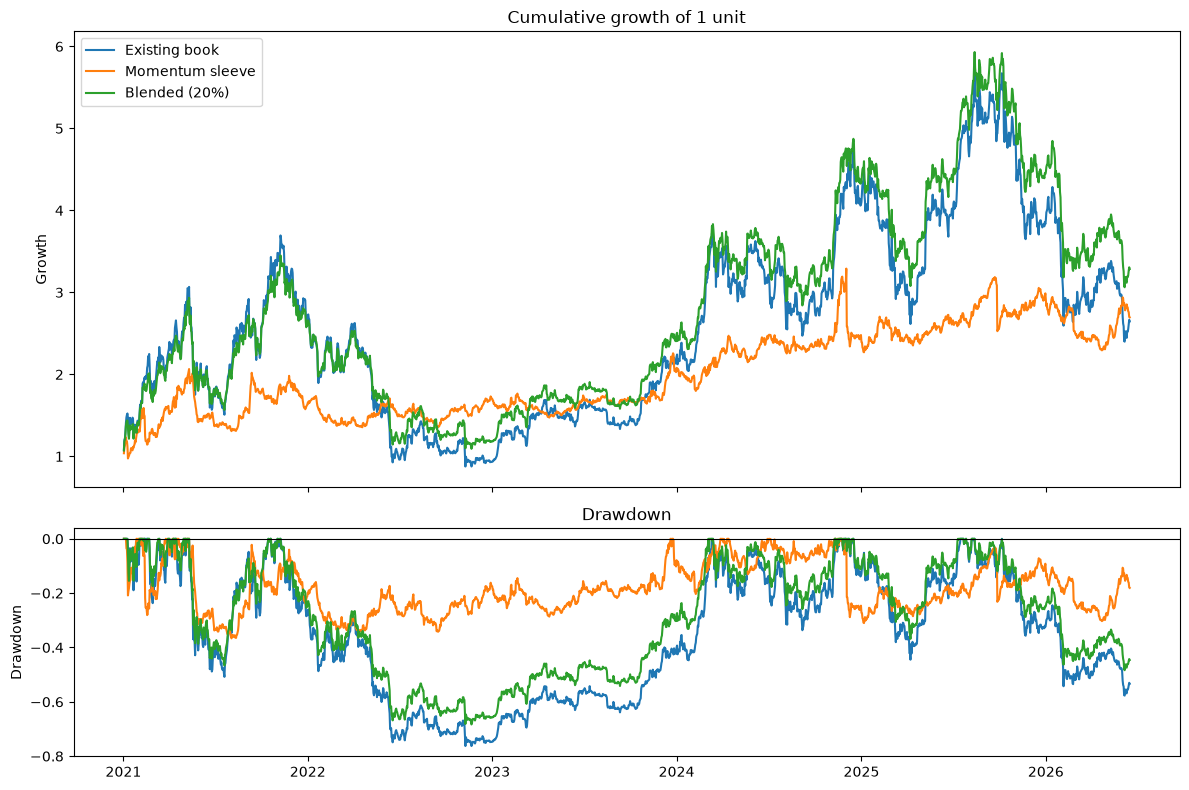

In [7]:
blended = (1 - ALLOCATION) * existing_aligned + ALLOCATION * sleeve_aligned

stats = pd.DataFrame(
    {
        "Existing book": perf_stats(existing_aligned),
        f"{FACTOR_LABEL} sleeve": perf_stats(sleeve_aligned),
        f"Blended ({ALLOCATION:.0%})": perf_stats(blended),
    }
).T[["CAGR", "Vol", "Sharpe", "Max drawdown"]]
print(stats.to_string(float_format=lambda x: f"{x:,.4f}"))

plot_cumulative_and_drawdown(
    {
        "Existing book": existing_aligned,
        f"{FACTOR_LABEL} sleeve": sleeve_aligned,
        f"Blended ({ALLOCATION:.0%})": blended,
    }
)

### Takeaways

A low or negative correlation is the point -- the sleeve adds a return stream
your book doesn't already own. Most teams start at a **10-25%** allocation and
size from there.

The committed copy of this notebook is rendered against the full dataset. Run
it yourself and it works out of the box on the shared public **demo key**,
which serves **preview data**; sign up for a key to work with the full history.

- Create an account and generate an API key at
  [factors.aperiodic.io](https://factors.aperiodic.io)
- This factor's factsheet:
  [factors.aperiodic.io/catalog/momentum](https://factors.aperiodic.io/catalog/momentum)
- Licensing & data access:
  [factors.aperiodic.io/booking](https://factors.aperiodic.io/booking)